In [4]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display settings
pd.set_option('display.max_columns', None)

In [6]:
df = pd.read_csv("diamonds.csv")

In [7]:
print(df.shape)
df.head()

(53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [9]:
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [10]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


#Data Cleaning

In [11]:
print((df[['x', 'y', 'z']] == 0).sum())

x     8
y     7
z    20
dtype: int64


In [12]:
df[['x', 'y', 'z']] = df[['x', 'y', 'z']].replace(0, np.nan)

In [13]:
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,8
y,7
z,20


In [14]:
df = df.dropna()

In [15]:
df = df.drop_duplicates()

In [16]:
df.reset_index(drop=True, inplace=True)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53775 entries, 0 to 53774
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53775 non-null  float64
 1   cut      53775 non-null  object 
 2   color    53775 non-null  object 
 3   clarity  53775 non-null  object 
 4   depth    53775 non-null  float64
 5   table    53775 non-null  float64
 6   price    53775 non-null  int64  
 7   x        53775 non-null  float64
 8   y        53775 non-null  float64
 9   z        53775 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [18]:
print((df[['x', 'y', 'z']] == 0).sum())

x    0
y    0
z    0
dtype: int64


In [19]:
df.shape

(53775, 10)

#Exploratory Data Analysis

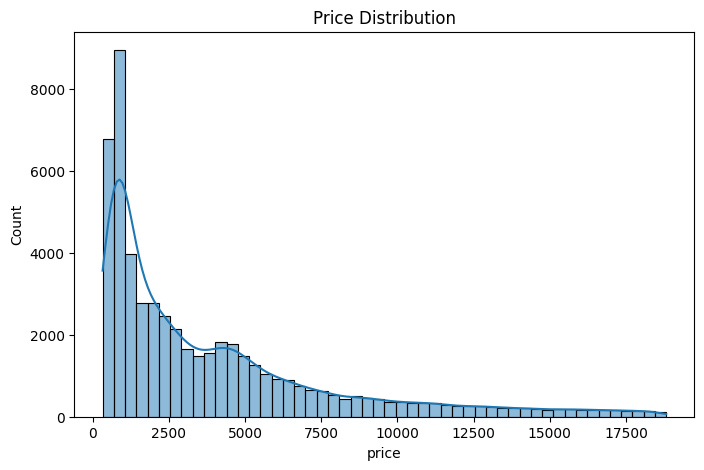

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Price Distribution")
plt.show()

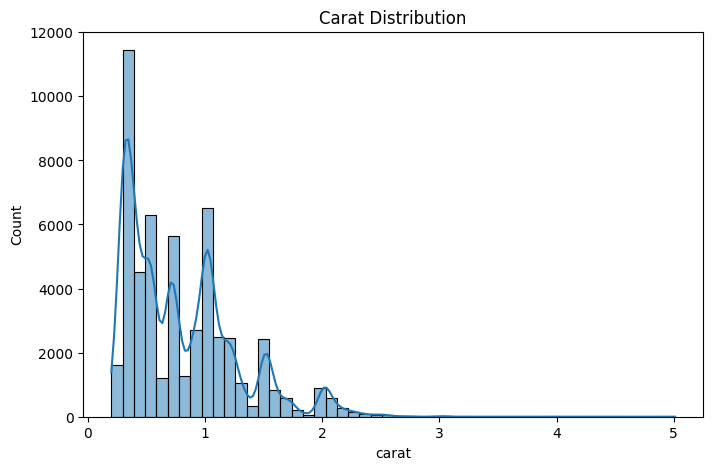

In [21]:
#Distribution of Carat
plt.figure(figsize=(8,5))
sns.histplot(df['carat'], bins=50, kde=True)
plt.title("Carat Distribution")
plt.show()

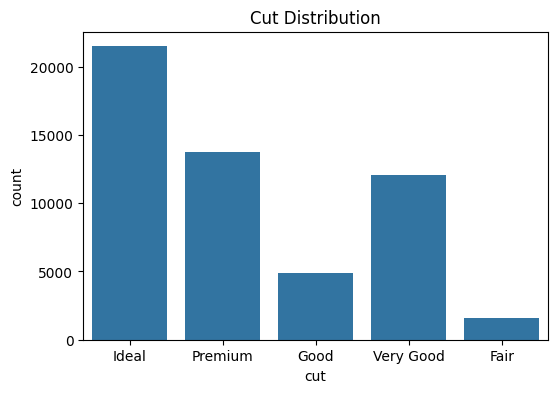

In [22]:
#Count plots (categorical)
plt.figure(figsize=(6,4))
sns.countplot(x='cut', data=df)
plt.title("Cut Distribution")
plt.show()

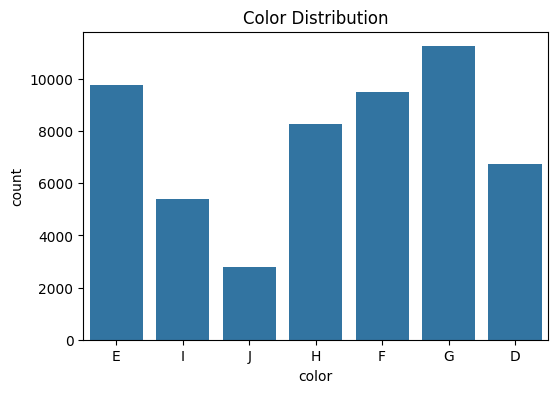

In [23]:
#Count plots (categorical)
plt.figure(figsize=(6,4))
sns.countplot(x='color', data=df)
plt.title("Color Distribution")
plt.show()



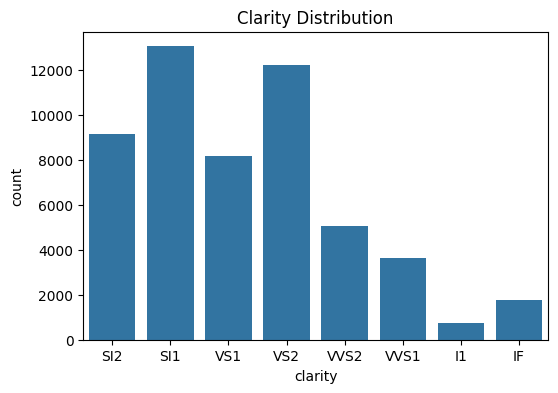

In [24]:
#Count plots (categorical)
plt.figure(figsize=(6,4))
sns.countplot(x='clarity', data=df)
plt.title("Clarity Distribution")
plt.show()

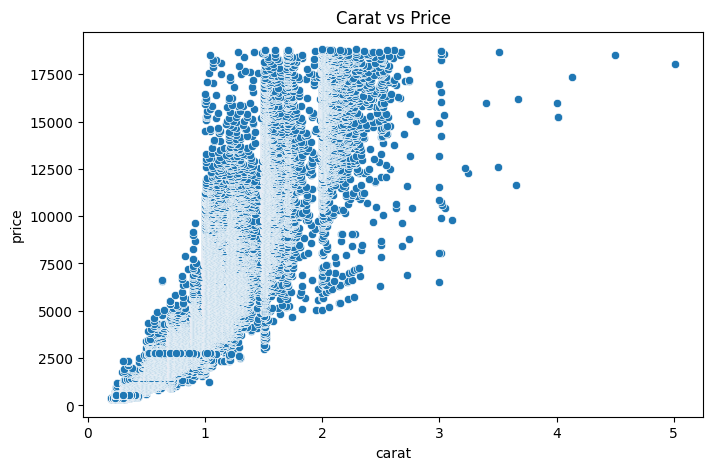

In [25]:
#Price vs Carat
plt.figure(figsize=(8,5))
sns.scatterplot(x='carat', y='price', data=df)
plt.title("Carat vs Price")
plt.show()

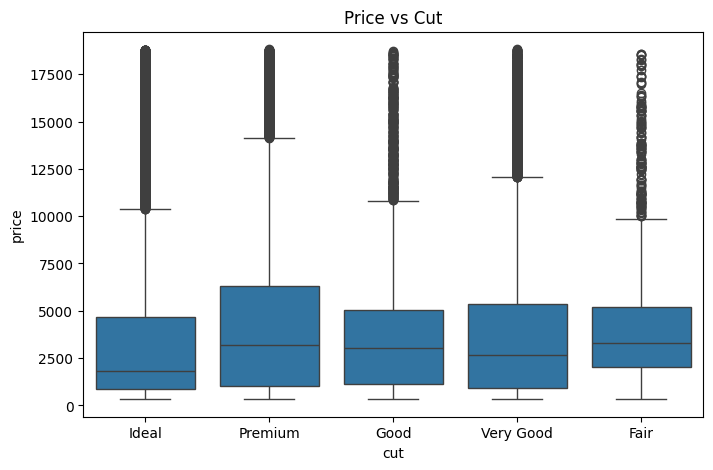

In [26]:
#Boxplots (price vs categories)
plt.figure(figsize=(8,5))
sns.boxplot(x='cut', y='price', data=df)
plt.title("Price vs Cut")
plt.show()

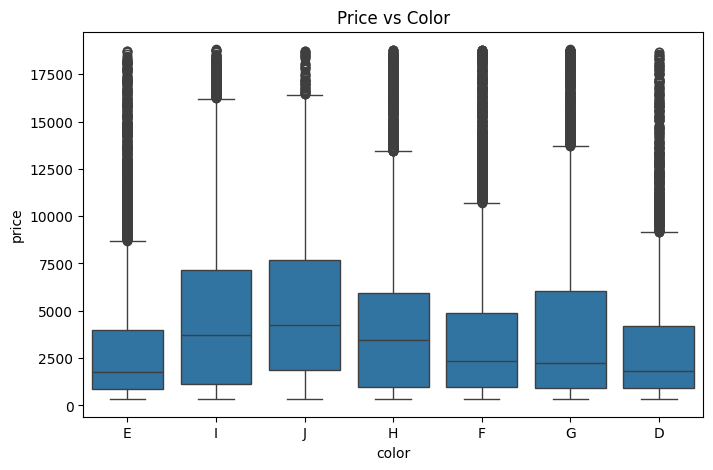

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x='color', y='price', data=df)
plt.title("Price vs Color")
plt.show()




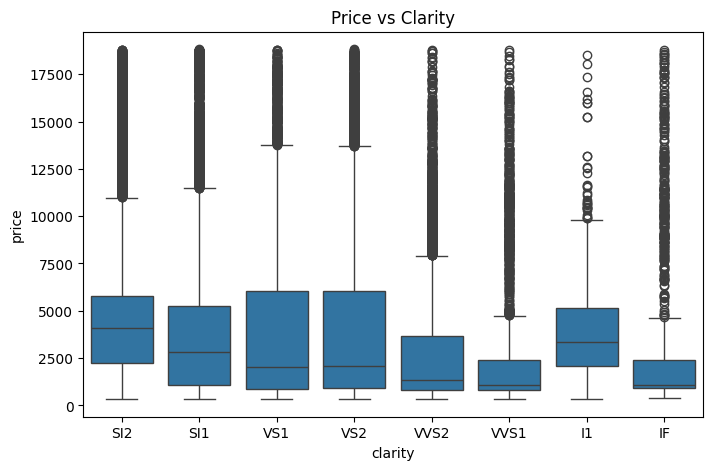

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(x='clarity', y='price', data=df)
plt.title("Price vs Clarity")
plt.show()

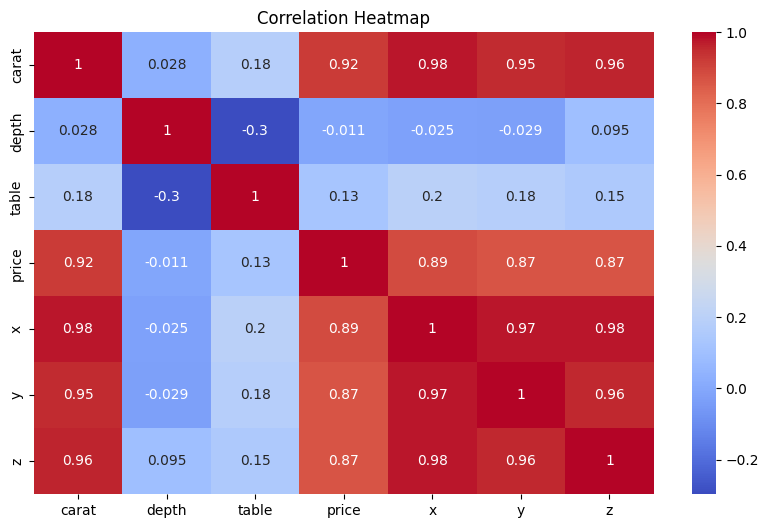

In [29]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

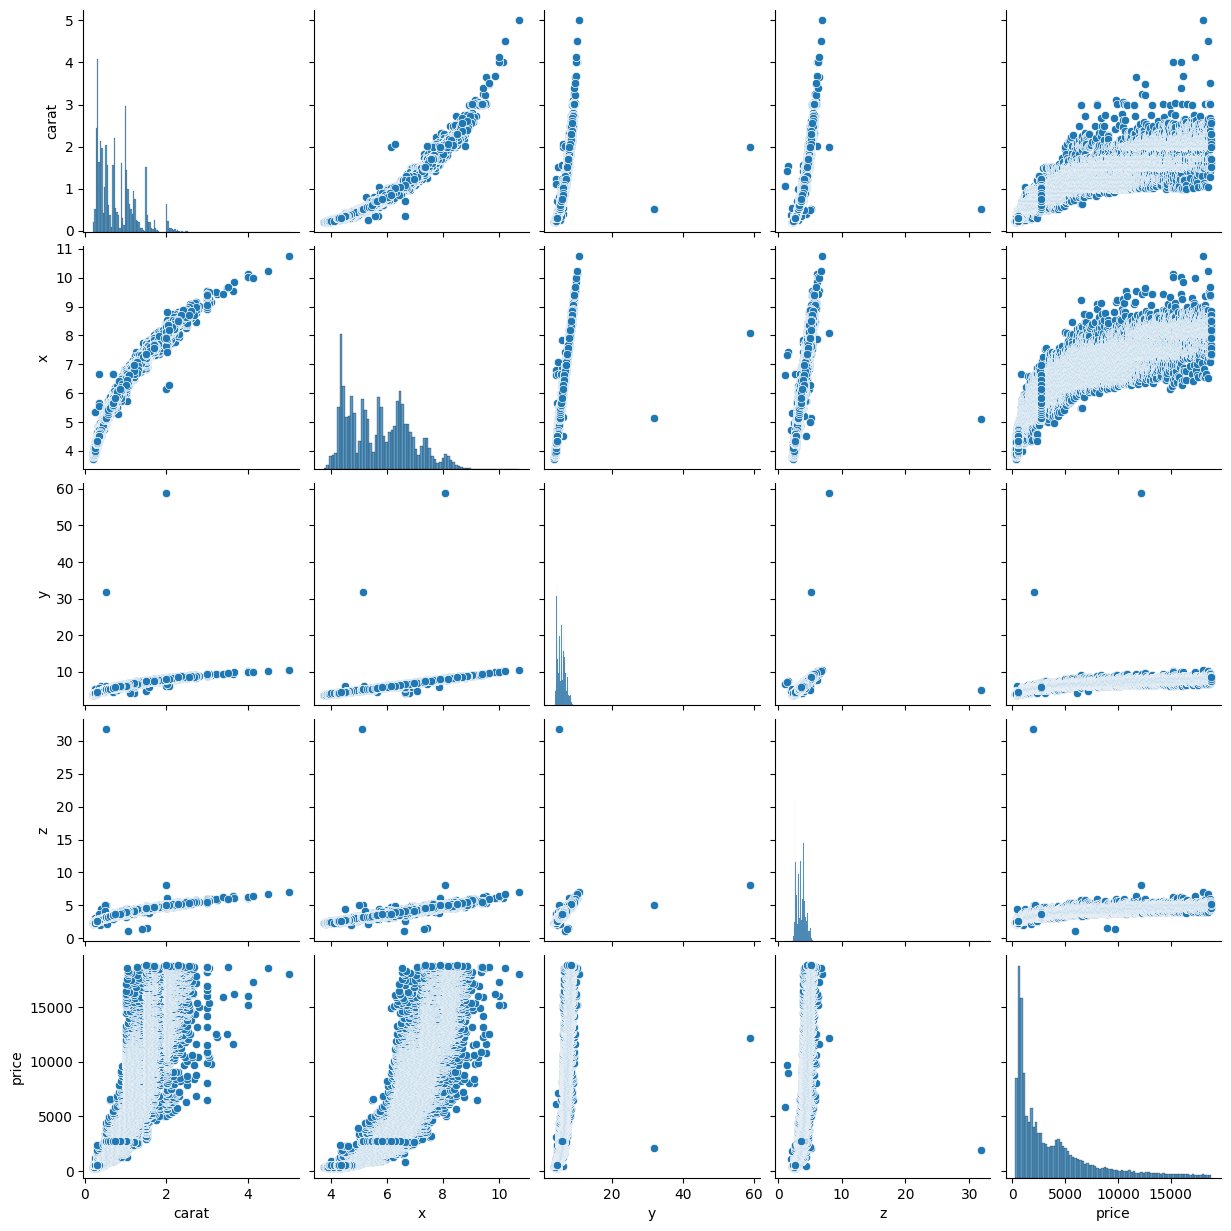

In [30]:
#Pairplot
sns.pairplot(df[['carat','x','y','z','price']])
plt.show()

#Feature Engineering

In [31]:
df['price_inr'] = df['price'] * 83   # approx conversion

In [32]:
df['volume'] = df['x'] * df['y'] * df['z']

In [33]:
df['price_per_carat'] = df['price'] / df['carat']

In [34]:
df['dimension_ratio'] = (df['x'] + df['y']) / (2 * df['z'])

In [35]:
def carat_category(carat):
    if carat < 0.5:
        return 'Light'
    elif carat <= 1.5:
        return 'Medium'
    else:
        return 'Heavy'

df['carat_category'] = df['carat'].apply(carat_category)

In [36]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,price_inr,volume,price_per_carat,dimension_ratio,carat_category
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,27058,38.202030,1417.391304,1.631687,Light
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,27058,34.505856,1552.380952,1.673160,Light
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,27141,38.076885,1421.739130,1.757576,Light
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,27722,46.724580,1151.724138,1.602662,Light
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,27805,51.917250,1080.645161,1.580000,Light


#Encoding + Feature Selection

In [37]:
df = df.drop(columns=['price_per_carat'])

In [38]:
X = df.drop(columns=['price', 'price_inr'])
y = df['price']

In [39]:
#Applying encoding

from sklearn.preprocessing import OrdinalEncoder

cat_cols = ['cut', 'color', 'clarity', 'carat_category']

encoder = OrdinalEncoder()
X[cat_cols] = encoder.fit_transform(X[cat_cols])

In [40]:
X.head()

,carat,cut,color,clarity,depth,table,x,y,z,volume,dimension_ratio,carat_category
0,0.23,2.0,1.0,3.0,61.5,55.0,3.95,3.98,2.43,38.202030,1.631687,1.0
1,0.21,3.0,1.0,2.0,59.8,61.0,3.89,3.84,2.31,34.505856,1.673160,1.0
2,0.23,1.0,1.0,4.0,56.9,65.0,4.05,4.07,2.31,38.076885,1.757576,1.0
3,0.29,3.0,5.0,5.0,62.4,58.0,4.20,4.23,2.63,46.724580,1.602662,1.0
4,0.31,1.0,6.0,3.0,63.3,58.0,4.34,4.35,2.75,51.917250,1.580000,1.0


In [41]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
print(X_train.shape)
print(X_test.shape)

(43020, 12)
(10755, 12)


#Regression Models

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [45]:
#Create evaluation function
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

In [46]:
#Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression Results:")
evaluate_model(y_test, y_pred_lr)

Linear Regression Results:
MAE: 847.3257465724499
MSE: 1735834.8036726129
RMSE: 1317.5108362638287
R2 Score: 0.8901595114496879


In [47]:
#Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("\nDecision Tree Results:")
evaluate_model(y_test, y_pred_dt)


Decision Tree Results:
MAE: 354.0100418410042
MSE: 531590.6178986517
RMSE: 729.1026113645813
R2 Score: 0.9663619066427228


In [48]:
#Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Results:")
evaluate_model(y_test, y_pred_rf)


Random Forest Results:
MAE: 268.00410871576895
MSE: 281424.0361613169
RMSE: 530.4941433807888
R2 Score: 0.9821919957150543


In [49]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("\nKNN Results:")
evaluate_model(y_test, y_pred_knn)


KNN Results:
MAE: 418.92403533240355
MSE: 701350.5826424918
RMSE: 837.4667650972734
R2 Score: 0.9556198029446661


#Clustering


In [50]:
X_cluster = df.drop(columns=['price', 'price_inr'])

In [51]:
#Encode Categorial columns
from sklearn.preprocessing import OrdinalEncoder

cat_cols = ['cut', 'color', 'clarity', 'carat_category']

encoder_cluster = OrdinalEncoder()
X_cluster[cat_cols] = encoder_cluster.fit_transform(X_cluster[cat_cols])

In [52]:
from sklearn.preprocessing import StandardScaler

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

In [53]:
#Find optimal clusters (Elbow Method)
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

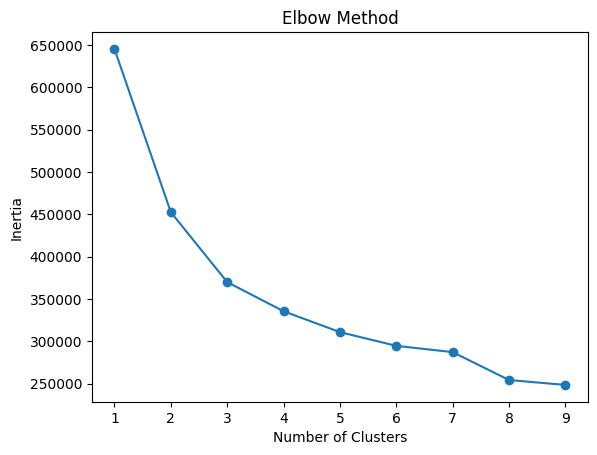

In [54]:
#Plot Elbow Curve
import matplotlib.pyplot as plt

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [55]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_cluster_scaled)

In [56]:
df.groupby('cluster')[['carat', 'price']].mean()

,carat,price
cluster,,
0,0.976820,4912.206663
1,0.398122,1052.540595
2,1.805906,12576.155239


In [57]:
cluster_names = {
    0: "Mid-range Balanced Diamonds",
    1: "Affordable Small Diamonds",
    2: "Premium Heavy Diamonds"
}

df['cluster_name'] = df['cluster'].map(cluster_names)

#Save Models

In [58]:
#Save Regression Model
import pickle

with open("rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)

In [59]:
#Save Scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [60]:
#save encoder
with open("encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

In [61]:
#Save Clustering Model
with open("kmeans.pkl", "wb") as f:
    pickle.dump(kmeans, f)

In [62]:
#Save clustering scaler + encoder
with open("scaler_cluster.pkl", "wb") as f:
    pickle.dump(scaler_cluster, f)

with open("encoder_cluster.pkl", "wb") as f:
    pickle.dump(encoder_cluster, f)

#Streamlit App

In [66]:
!pip install streamlit pyngrok

In [68]:
!ngrok authtoken 39FTXeiYaiaRbm41ZYX0li8ULyM_4mbFqnwWZ45Qa1MWeEVcG

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [72]:
from pyngrok import ngrok
import subprocess
import time

# Start streamlit in background
get_ipython().system_raw('streamlit run app.py &')

# Wait for server to start
time.sleep(5)

# Open tunnel
public_url = ngrok.connect(8501)
print("Streamlit App URL:", public_url)

Streamlit App URL: NgrokTunnel: "https://unreverent-herminia-unallusively.ngrok-free.dev" -> "http://localhost:8501"
